# Gradients and optimisation

Every jbubble simulation is a JAX function, so `jax.grad` differentiates any scalar result with respect to any model input, straight through the ODE solve. In this example, you check a gradient against finite differences, compute a whole sensitivity curve in one `jax.vmap(jax.grad(...))` call, and use the gradient to climb a response map with an optax optimiser.

In [ ]:
# Install jbubble on Google Colab, or anywhere it's missing.
import importlib.util

if importlib.util.find_spec("jbubble") is None:
    %pip install --quiet "jbubble[examples]==0.2.0"

In [1]:
import os
import time

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax

from jbubble import SaveSpec, run_simulation
from jbubble.bubble.eom import KellerMiksis
from jbubble.bubble.gas import PolytropicGas
from jbubble.bubble.medium import NewtonianMedium
from jbubble.bubble.shell import NoShell
from jbubble.fitting import Parameter, unwrap
from jbubble.pulse import HannEnvelope, ToneBurst
from jbubble.pulse.shapes import Sine
from jbubble.utils import GridSweep

plt.style.use("jbubble.style.light")

# Set JBUBBLE_QUICK=1 for a fast, coarse run (used by CI).
QUICK = os.environ.get("JBUBBLE_QUICK") == "1"

## A differentiable response

The model is a free air bubble in water, solved with the Keller-Miksis equation and driven by a six-cycle, Hann-windowed tone burst. The response is the peak expansion $R_\text{max}/R_0$.

`jnp.max` passes its gradient through one saved sample only, so the gradient jumps whenever a different sample becomes the largest. A soft maximum, $\frac{1}{\beta}\log\frac{1}{N}\sum_i e^{\beta r_i}$, blends the samples near the peak and gives a smoother objective. It sits slightly below the true maximum, by at most $\log(N)/\beta$: about 0.1 for $N = 256$ samples and $\beta = 50$.

In [2]:
SAVE_SPEC = SaveSpec(256)
T_MAX = 8e-6  # [s]


def simulate(freq, R0, pressure, mu=1e-3):
    eom = KellerMiksis(
        gas=PolytropicGas(gamma=1.4),
        shell=NoShell(sigma=0.072),
        medium=NewtonianMedium(mu=mu, rho_L=998.0, c_L=1500.0),
        R0=R0,
        P_amb=101325.0,
    )
    pulse = ToneBurst(
        freq=freq, pressure=pressure, shape=Sine(), cycle_num=6, envelope=HannEnvelope()
    )
    return run_simulation(eom, pulse, save_spec=SAVE_SPEC, t_max=T_MAX)


def soft_peak(x, beta=50.0):
    """Smooth maximum of a 1-D array."""
    return (jax.nn.logsumexp(beta * x) - jnp.log(x.shape[0])) / beta


def response(params):
    """Peak expansion R_max / R0 for a dict of model inputs."""
    result = simulate(params["freq"], params["R0"], params["pressure"], params["mu"])
    return soft_peak(result.radius / params["R0"])

## Check a gradient against finite differences

`jax.grad(response)` returns a dict with the same keys as its input, one derivative per model input. The following cell compares each derivative with a central finite difference. To compare inputs with different units, it prints the relative sensitivity $x\,\partial y/\partial x$: the change in $R_\text{max}/R_0$ for a 100 % change in $x$.

In [3]:
params = {"freq": 1.5e6, "R0": 2e-6, "pressure": 80e3, "mu": 1e-3}

response_jit = jax.jit(response)
grad_jit = jax.jit(jax.grad(response))
grads = grad_jit(params)

print(f"R_max/R0 = {float(response_jit(params)):.4f}")
print(f"{'input':>8}  {'jax.grad':>10}  {'finite diff.':>12}  {'rel. diff.':>10}")
for name, x in params.items():
    h = 1e-4 * x
    up = response_jit({**params, name: x + h})
    down = response_jit({**params, name: x - h})
    fd = (up - down) / (2 * h)
    print(
        f"{name:>8}  {x * float(grads[name]):+10.4f}  {x * float(fd):+12.4f}"
        f"  {abs(float(grads[name] / fd) - 1):10.1e}"
    )

R_max/R0 = 1.2371
   input    jax.grad  finite diff.  rel. diff.
    freq     +1.8615       +1.8613     1.1e-04
      R0     +2.3814       +2.3813     7.7e-06
pressure     +0.4495       +0.4495     6.9e-05
      mu     -0.0399       -0.0399     1.4e-04


The two agree to about $10^{-4}$, within the accuracy that the default solver tolerances allow. One `jax.grad` call returns every derivative at once, whereas finite differences need two simulations per input.

## Map sensitivities with `vmap(grad)`

`jax.vmap` maps the gradient over a batch of inputs. The following cell computes the response and its derivative with respect to the driving frequency at once, for every frequency in the sweep. The derivative crosses zero at the resonance peak.

120 responses and gradients in 10.2 s
Resonance peak at 1.87 MHz


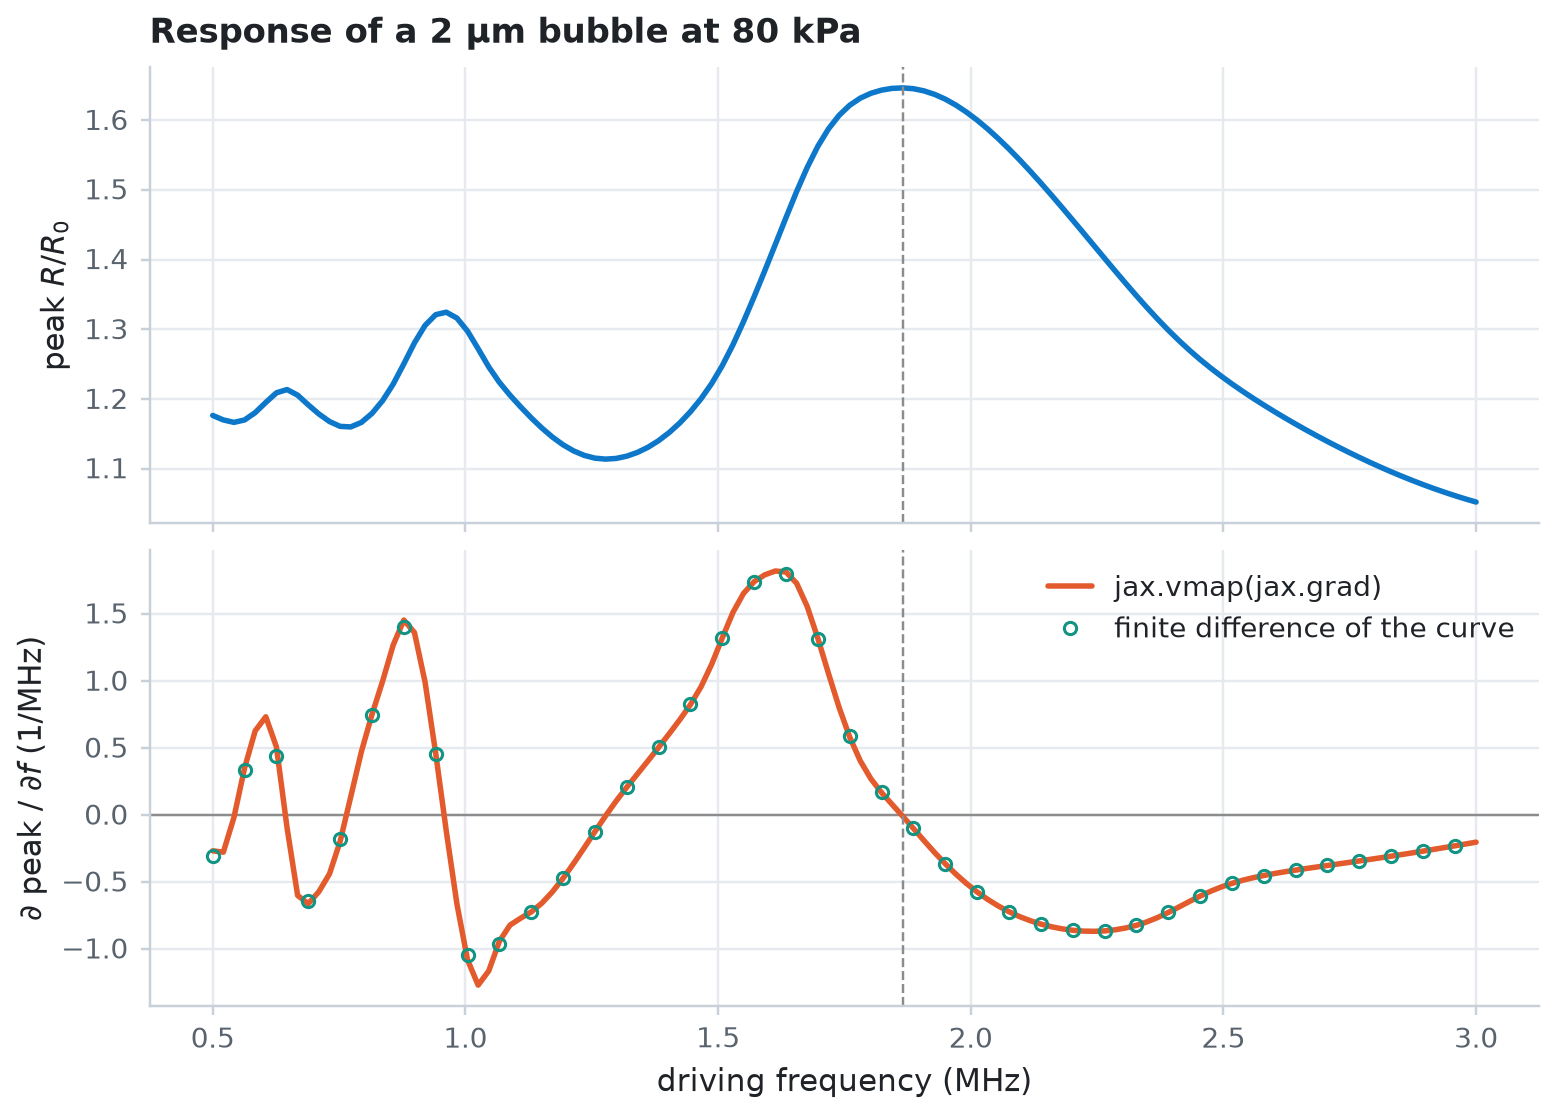

In [4]:
freqs = jnp.linspace(0.5e6, 3.0e6, 40 if QUICK else 120)


def response_at(freq):
    return response({**params, "freq": freq})


start = time.perf_counter()
values, slopes = jax.jit(jax.vmap(jax.value_and_grad(response_at)))(freqs)
slopes.block_until_ready()
print(f"{len(freqs)} responses and gradients in {time.perf_counter() - start:.1f} s")

peak = int(jnp.argmax(values))
print(f"Resonance peak at {float(freqs[peak]) / 1e6:.2f} MHz")

f_mhz = np.asarray(freqs) / 1e6
fig, (ax_r, ax_g) = plt.subplots(2, 1, figsize=(7, 5), sharex=True)
ax_r.plot(f_mhz, values, color="C0")
ax_r.set_ylabel(r"peak $R/R_0$")
ax_r.set_title("Response of a 2 µm bubble at 80 kPa")
# d(response)/d(freq) per MHz, from jax.grad and from the sampled curve.
ax_g.axhline(0.0, color="0.55", lw=0.8)
ax_g.plot(f_mhz, np.asarray(slopes) * 1e6, color="C1", label="jax.vmap(jax.grad)")
ax_g.plot(
    f_mhz[::3],
    np.gradient(np.asarray(values), f_mhz)[::3],
    "o",
    ms=4,
    mfc="none",
    color="C2",
    label="finite difference of the curve",
)
ax_g.set_xlabel("driving frequency (MHz)")
ax_g.set_ylabel(r"$\partial$ peak / $\partial f$ (1/MHz)")
ax_g.legend(loc="upper right")
for ax in (ax_r, ax_g):
    ax.axvline(f_mhz[peak], color="0.55", lw=0.8, ls="--")
plt.show()

## Climb a response map with optax

Suppose you want the bubble size and driving frequency that give the largest expansion. Over frequency $f$ and radius $R_0$ at a fixed pressure, the response has no single peak: the resonance ridge keeps rising toward large bubbles at low frequency. A real transducer delivers its rated pressure only within its passband, here a Gaussian centred on 1.5 MHz:

$$
p(f) = p_0 \exp\left[-\frac{1}{2}\left(\frac{f - f_c}{\Delta f}\right)^2\right].
$$

The passband turns the ridge into a single peak. The following cell maps the objective with [`GridSweep`](https://imperial-nsb.github.io/jbubble/api/utils/#jbubble.utils.gridsweep.GridSweep), which evaluates `objective` over the grid in parallel batches.

In [5]:
P0, F_CENTRE, BANDWIDTH = 80e3, 1.5e6, 0.45e6  # [Pa], [Hz], [Hz]
F_RANGE = (0.5e6, 3.0e6)  # [Hz]
R0_RANGE = (1e-6, 5e-6)  # [m]


def objective(freq, R0):
    pressure = P0 * jnp.exp(-0.5 * ((freq - F_CENTRE) / BANDWIDTH) ** 2)
    return soft_peak(simulate(freq, R0, pressure).radius / R0)


n_grid = 32 if QUICK else 120
search_space = {
    "R0": jnp.linspace(*R0_RANGE, n_grid),
    "freq": jnp.linspace(*F_RANGE, n_grid),
}
start = time.perf_counter()
# GridSweep orders the axes by name, so the map has shape (R0, freq).
response_map = GridSweep(objective, search_space, progress=False).run()
print(f"{n_grid}x{n_grid} map in {time.perf_counter() - start:.1f} s")

i_best, j_best = np.unravel_index(np.argmax(response_map), response_map.shape)
grid_best = {
    "freq": float(search_space["freq"][j_best]),
    "R0": float(search_space["R0"][i_best]),
}
print(
    f"Grid maximum: {response_map.max():.3f} at {grid_best['freq'] / 1e6:.2f} MHz, "
    f"R0 = {grid_best['R0'] * 1e6:.2f} µm"
)

120x120 map in 4.6 s
Grid maximum: 1.740 at 1.45 MHz, R0 = 2.51 µm


The climb starts from a poor guess, a 4.2 µm bubble at 2.7 MHz, far up the flat shoulder of the map. Each [`Parameter`](https://imperial-nsb.github.io/jbubble/api/fitting/#jbubble.fitting.Parameter) keeps its value inside the map's range. The optimiser updates an unconstrained coordinate of order one, and [`unwrap`](https://imperial-nsb.github.io/jbubble/api/fitting/#jbubble.fitting.unwrap) turns it back into physical units, so one learning rate suits both a frequency in hertz and a radius in metres. `eqx.partition` separates the arrays that the optimiser updates from the bounds, which stay fixed.

In [6]:
start_point = {
    "freq": Parameter(2.7e6, lower=F_RANGE[0], upper=F_RANGE[1]),
    "R0": Parameter(4.2e-6, lower=R0_RANGE[0], upper=R0_RANGE[1]),
}
trainable, static = eqx.partition(start_point, eqx.is_inexact_array)
optimizer = optax.adam(0.1)
opt_state = optimizer.init(trainable)


def loss(trainable):
    p = unwrap(eqx.combine(trainable, static))
    return -objective(p["freq"], p["R0"])  # optimisers minimise


@eqx.filter_jit
def step(trainable, opt_state):
    value, grads = jax.value_and_grad(loss)(trainable)
    updates, opt_state = optimizer.update(grads, opt_state, trainable)
    return eqx.apply_updates(trainable, updates), opt_state, -value


n_steps = 20 if QUICK else 60
path, history = [], []
start = time.perf_counter()
for _ in range(n_steps):
    p = unwrap(eqx.combine(trainable, static))
    path.append((float(p["freq"]), float(p["R0"])))
    trainable, opt_state, value = step(trainable, opt_state)
    history.append(float(value))
p = unwrap(eqx.combine(trainable, static))
path.append((float(p["freq"]), float(p["R0"])))
final = float(objective(p["freq"], p["R0"]))
path = np.array(path)

print(f"{n_steps} optax steps in {time.perf_counter() - start:.1f} s")
print(
    f"Optimum: {final:.3f} at {path[-1, 0] / 1e6:.2f} MHz, "
    f"R0 = {path[-1, 1] * 1e6:.2f} µm (grid maximum {response_map.max():.3f})"
)

60 optax steps in 10.3 s
Optimum: 1.739 at 1.46 MHz, R0 = 2.52 µm (grid maximum 1.740)


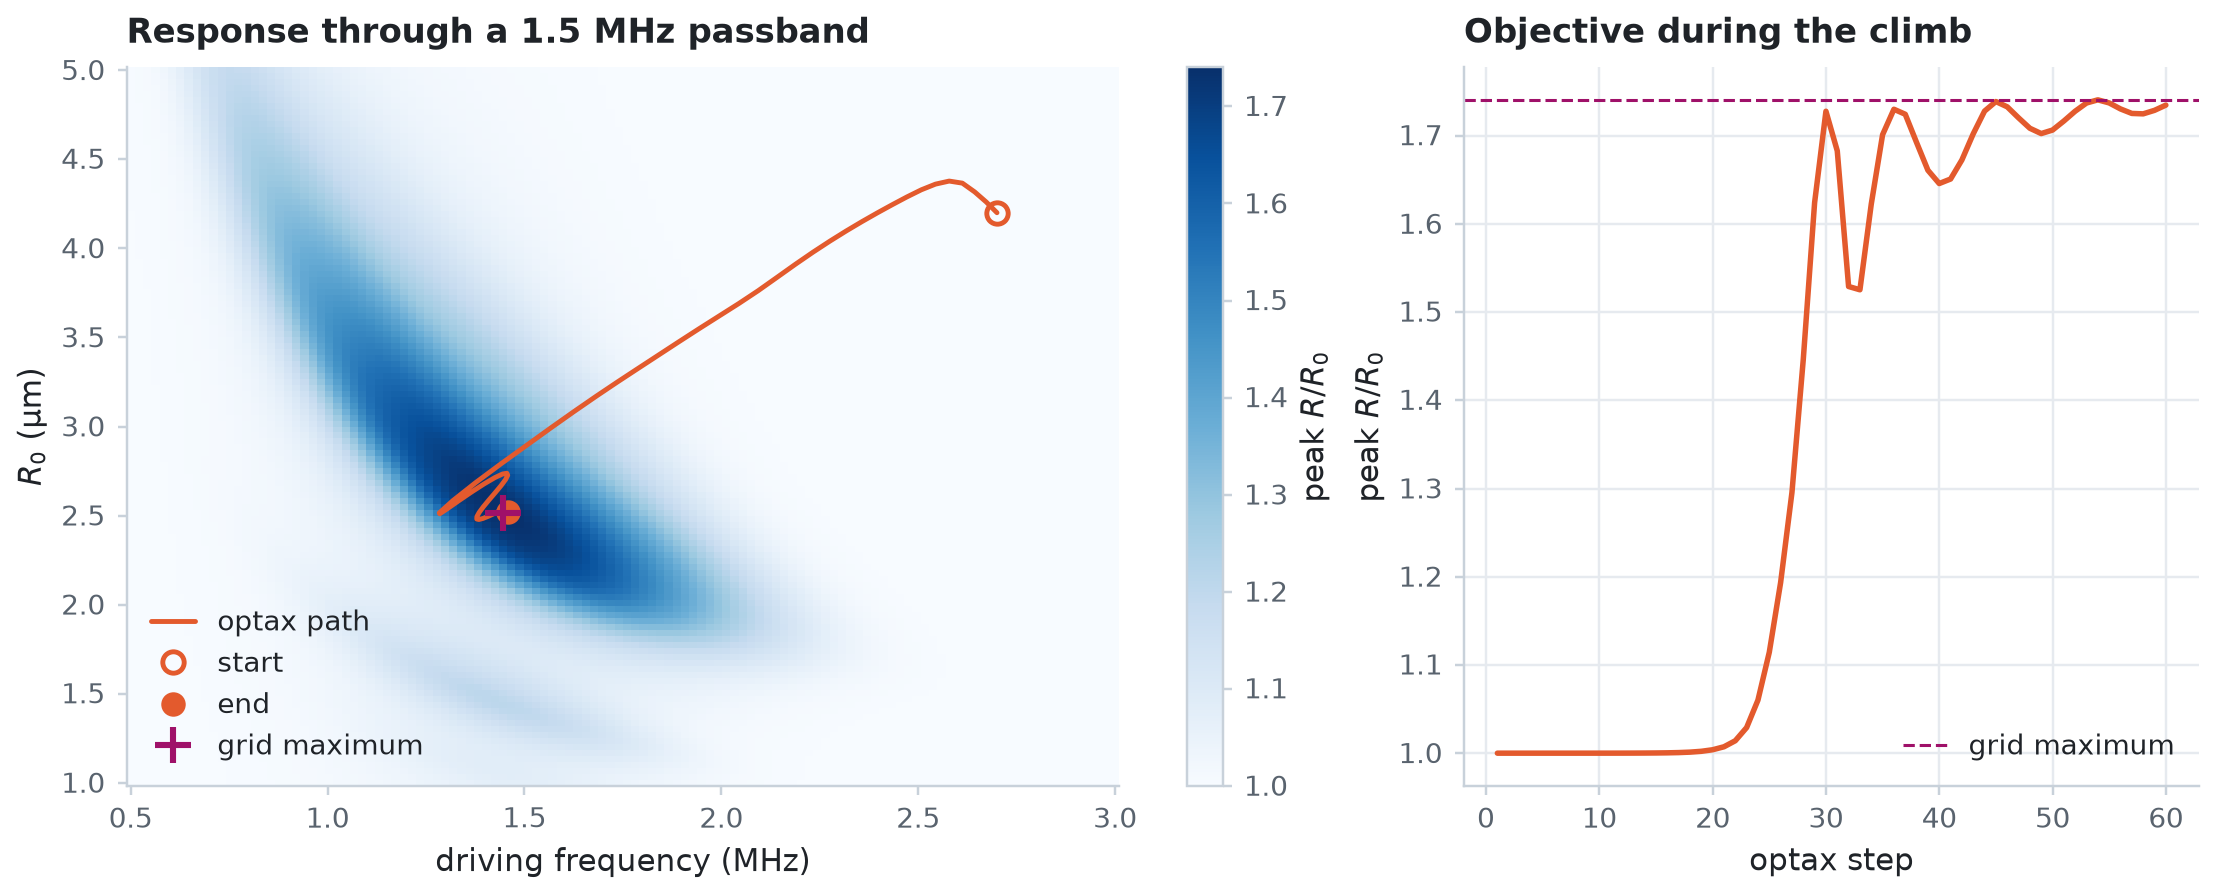

In [7]:
fig, (ax_m, ax_h) = plt.subplots(
    1, 2, figsize=(10, 4), gridspec_kw={"width_ratios": [1.35, 1]}
)
mesh = ax_m.pcolormesh(
    np.asarray(search_space["freq"]) / 1e6,
    np.asarray(search_space["R0"]) * 1e6,
    response_map,
    shading="auto",
    rasterized=True,
)
fig.colorbar(mesh, ax=ax_m, label=r"peak $R/R_0$")
ax_m.grid(False)
ax_m.plot(path[:, 0] / 1e6, path[:, 1] * 1e6, color="C1", lw=1.6, label="optax path")
ax_m.plot(
    path[0, 0] / 1e6,
    path[0, 1] * 1e6,
    "o",
    ms=7,
    mfc="none",
    mec="C1",
    mew=1.6,
    label="start",
)
ax_m.plot(path[-1, 0] / 1e6, path[-1, 1] * 1e6, "o", ms=7, color="C1", label="end")
ax_m.plot(
    grid_best["freq"] / 1e6,
    grid_best["R0"] * 1e6,
    "+",
    ms=12,
    mew=2,
    color="C3",
    label="grid maximum",
)
ax_m.set_xlabel("driving frequency (MHz)")
ax_m.set_ylabel(r"$R_0$ (µm)")
ax_m.set_title("Response through a 1.5 MHz passband")
ax_m.legend(loc="lower left")

ax_h.plot(np.arange(1, n_steps + 1), history, color="C1")
ax_h.axhline(response_map.max(), color="C3", lw=1.0, ls="--", label="grid maximum")
ax_h.set_xlabel("optax step")
ax_h.set_ylabel(r"peak $R/R_0$")
ax_h.set_title("Objective during the climb")
ax_h.legend(loc="lower right")
plt.show()

The objective barely changes for the first 20 steps, yet the path crosses the flat shoulder of the map at a steady pace: Adam divides each step by the recent size of the gradient, so even a tiny gradient moves it. The path then turns along the ridge and reaches the peak after a few dozen simulations and their gradients, whereas the map needs one simulation per grid point. With a constant learning rate, Adam keeps oscillating slightly about the peak; a decaying learning rate, such as `optax.cosine_decay_schedule`, settles it.

To fit model parameters to measured data instead of maximising a response, use [`fit_parameters`](https://imperial-nsb.github.io/jbubble/api/fitting/#jbubble.fitting.fit_parameters), which wraps this loop and retries failed steps. Examples 10 and 11 use it.